# Determining how common large events are.

This notebook will identify how many days it takes to reach a certain amount of precipitation each year. 

We will try to answer the following questions: 
1) Is it many days? 
2) Only a few days?
3) Is it variable year-to-year?

We will use three datasets to do this: billy_barr_precip data, 2 local snotel sites (Butte and Schofield Pass), and PRISM. These 3 datasets will try to establish how much variability is involved across space and time. 

In [29]:
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [182]:
DATA_DIR = "/storage/dlhogan/precipitation-rodeo/data/processed/"
# import snotel data
sntl_df = pd.read_csv(f"{DATA_DIR}final/east_river_snotel.csv", index_col=0, parse_dates=True)
sntl_df.index = pd.to_datetime(sntl_df.index.date)
# import billy barr data
bb_ds = xr.open_dataset(f"{DATA_DIR}/billy_barr/billy_barr_20011001-20251025_30min.nc")
# import PRISM data
# prism_ds


In [183]:
bb_valid_dates = slice("2016-10-01","2025-09-30")
bb_ds_filtered = bb_ds.sel(time=bb_valid_dates).where(bb_ds['precip']>=0)

flag_mask = (~bb_ds_filtered['precip_bad_flag'].astype(bool) | ~bb_ds_filtered['precip_missing_flag'].astype(bool))

bb_ds_filtered_daily = bb_ds_filtered.where(flag_mask, np.nan)['precip'].resample(time='1D').sum()
bb_precip_df = bb_ds_filtered_daily.to_dataframe()


In [184]:
bb_precip_df['WY'] = bb_precip_df.index.year.where(bb_precip_df.index.month<10, bb_precip_df.index.year+1)
sntl_df['WY'] = sntl_df.index.year.where(sntl_df.index.month<10, sntl_df.index.year+1)

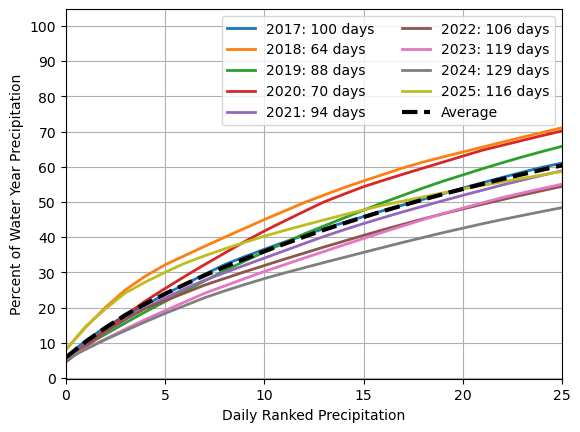

In [204]:
fig, ax = plt.subplots()

norm_list = []
for wy in bb_precip_df['WY'].unique():
    df = bb_precip_df[bb_precip_df['WY']==wy].sort_values('precip', ascending=False)['precip']
    days_with_precip = (df > 1).sum()
    # normalize by total precip
    df_norm = df/df.sum() * 100
    df_norm.reset_index(drop=True, inplace=True)
    df_norm.name = wy
    norm_list.append(df_norm)

    df_norm.cumsum().plot(ax=ax, lw=2, label=f"{wy}: {days_with_precip} days")
# plot average water year
avg_norm_df = pd.concat(norm_list, axis=1).mean(axis=1)
avg_norm_df.cumsum().plot(ax=ax, lw=3, ls='--', label="Average", color='k')

ax.set_xlim(0,25)
ax.set_yticks(range(0,110,10))
ax.set_ylabel("Percent of Water Year Precipitation")
ax.set_xlabel("Daily Ranked Precipitation")
ax.legend(ncol=2)
ax.grid()

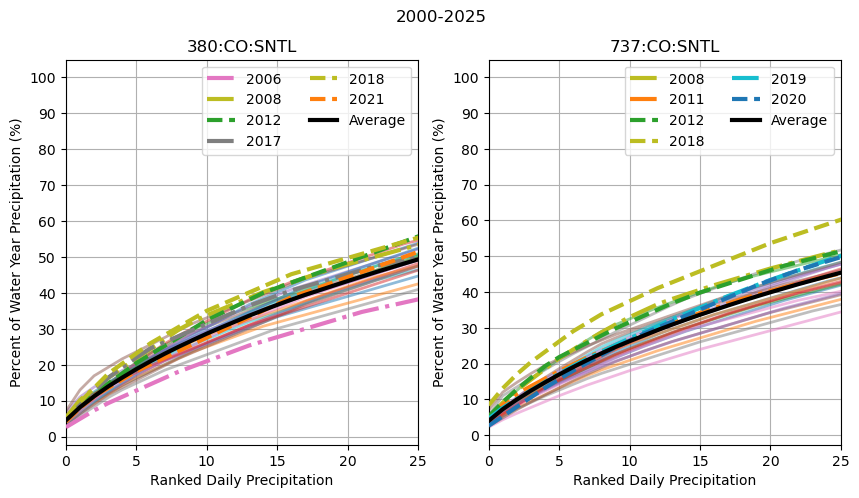

In [198]:
fig, axs = plt.subplots(ncols=2, figsize=(10,5))

ranked_years_list = []
for i,site in enumerate(sntl_df.site.unique()):
    df = sntl_df[sntl_df['site']==site]
    ranked_years = df.groupby('WY').sum('PRECIPITATION').sort_values('PRECIPITATION', ascending=False)
    ranked_years_list.append(ranked_years)
    norm_list = []
    for wy in sntl_df['WY'].unique():
        wy_df = df[df['WY']==wy].sort_values('PRECIPITATION', ascending=False)['PRECIPITATION']
        # normalize by total PRECIPITATION
        wy_df_norm = wy_df/wy_df.sum() * 100
        wy_df_norm.reset_index(drop=True, inplace=True)
        wy_df_norm.name = wy
        norm_list.append(wy_df_norm)

        if wy in ranked_years.iloc[0:3].index:
            wy_df_norm.cumsum().plot(ax=axs[i], lw=3, ls='-.',label=wy, zorder=100)
        elif wy in ranked_years.iloc[-3:].index:
            wy_df_norm.cumsum().plot(ax=axs[i], lw=3, ls='--', label=wy, zorder=100)
        else:
            wy_df_norm.cumsum().plot(ax=axs[i], lw=2, alpha=0.5, label='_')
    # plot average water year
    avg_norm_df = pd.concat(norm_list, axis=1).mean(axis=1)
    avg_norm_df.cumsum().plot(ax=axs[i], lw=3, ls='-', label="Average", color='k',zorder=101)

    axs[i].set_xlim(0,25)
    axs[i].set_yticks(range(0,110,10))
    axs[i].set_title(site)
    axs[i].set_ylabel("Percent of Water Year Precipitation (%)")
    axs[i].set_xlabel("Ranked Daily Precipitation")
    axs[i].legend(ncol=2)
    axs[i].grid()
    fig.suptitle('2000-2025')